In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('../data/transformed_df.csv')

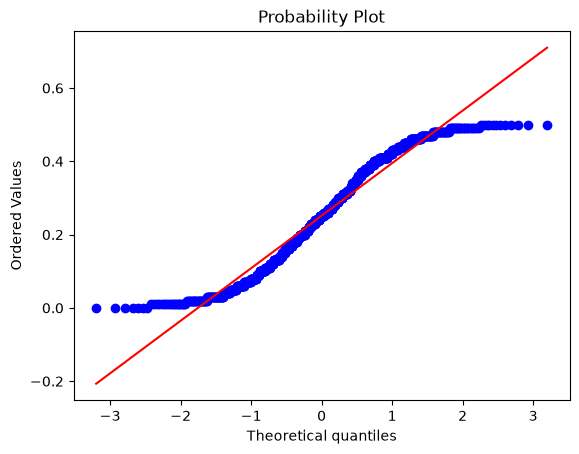

In [4]:
# Check if discounts are normally distributed
res = stats.probplot(df['Discount'], plot=plt)

In [5]:
# Additional test to see if discounts are not normally distributed

# Kolmogorov-Smirnov
res_discount = stats.kstest(df['Discount'], stats.norm.cdf)

print("Check p value for discount: ", res_discount.pvalue)




Check p value for discount:  1.064517291557782e-231


In [6]:
sales_mean = df['Sales'].mean()
sales_std = df['Sales'].std()

res_rating = stats.kstest(df['Sales'], stats.norm.cdf, args=(sales_mean, sales_std))

print(res_rating)

KstestResult(statistic=np.float64(0.0726264172529556), pvalue=np.float64(4.944805767374358e-05), statistic_location=np.float64(1517.0), statistic_sign=np.int8(-1))


### Discount data is not normally distributed. A KS Test was also conducted for additional test for normality - we got a p value less than 0.05 , proceeding with Spearman's test for correlation

In [7]:
# Test for correlation with Spearmen correlation

pearson_r, pearson_p = stats.pearsonr(df["Discount"], df["Sales"])
spearman_rho, spearman_p = stats.spearmanr(df["Discount"], df["Sales"])

print('Pearson Correlation: ', pearson_r)
print('', pearson_p)
print('Spearman Correlation: ', spearman_rho)
print(spearman_p)

Pearson Correlation:  0.02741346987045747
 0.38650741431858165
Spearman Correlation:  0.026632379372770375
0.4001879216315177


### Compare groups, see if one item performs better than another


In [10]:
# Sales per product

with pd.option_context('display.max_rows', None):
    print(df.groupby("ProductName")['Sales'].mean().sort_values(ascending=False))


ProductName
Mascara             1554.000000
Bamboo Sheets       1468.142857
Paint Set           1445.500000
Toy Car             1435.333333
Sketchbook          1421.000000
Cotton Sheets       1399.285714
Spark Plugs         1312.083333
Multivitamin        1288.166667
Weighted Blanket    1280.625000
Electric Blanket    1273.333333
Brake Pads          1271.818182
Wool Socks          1256.000000
Fantasy Book        1242.000000
Fish Oil            1236.200000
Cleanser            1222.000000
Phone Case          1199.600000
Rose Wine           1176.083333
Shower Gel          1171.166667
Screen Protector    1168.500000
Headphones          1162.769231
Grill Pan           1159.500000
Body Lotion         1158.000000
Nail Clippers       1154.500000
Road Bike           1150.125000
Earbuds             1149.000000
Coffee Mug          1139.666667
Tea Cup             1138.777778
Cuticle Oil         1135.000000
Knee-High Socks     1126.636364
Blender             1119.625000
Hybrid Bike         1117.285

In [ ]:
df["Category"].unique()

<ArrowStringArray>
[               'Electronics',                   'Clothing',
             'Home & Kitchen',                      'Books',
               'Toys & Games',   'Vitamins and supplements',
                  'Skin care',                     'Makeup',
          'Coats and jackets',                   'Bicycles',
 'Art and crafting materials',                  'Drinkware',
        'Perfume and cologne',                       'Wine',
                      'Socks',                  'Bedsheets',
        'Posters and artwork',                    'Candles',
              'Bath and body',                   'Cookware',
                  'Nail care',                  'Underwear',
        'Motor vehicle parts',   'Mobile phone accessories',
                   'Blankets']
Length: 25, dtype: str

In [33]:
electronics = df[df["Category"] == 'Electronics']

# Count of every product name

electronics.groupby("ProductName")["ProductName"].count()

ProductName
Headphones    13
Laptop        11
Smartphone     6
Smartwatch    10
Name: ProductName, dtype: int64

### We will now begin a series of non parametric tests, utilizing the Kruskal Wallis Test


In proceeding with our tests, I would like to segment data and have their own batch of tests in order to have structure in findings and insights

In [39]:
# Kruskal Wallis test on Electronics

# Segment the 4 product groups
headphones_sales = electronics[electronics['ProductName'] == 'Headphones']['Sales']
laptop_sales     = electronics[electronics['ProductName'] == 'Laptop']['Sales']
smartphone_sales = electronics[electronics['ProductName'] == 'Smartphone']['Sales']
smartwatch_sales = electronics[electronics['ProductName'] == 'Smartwatch']['Sales']

# 2. Run the Kruskal-Wallis Test
stat, p_value = stats.kruskal(headphones_sales, laptop_sales, smartphone_sales, smartwatch_sales)

# 3. Print the results
print(f"H-statistic: {stat:.4f}")
print(f"p-value: {p_value}")

H-statistic: 0.3239
p-value: 0.9554721444970609


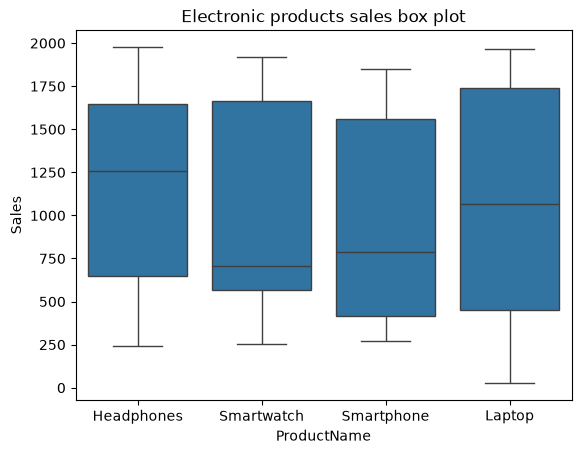

In [ ]:
# Box plot of four electronics

sns.boxplot(data=electronics, x='ProductName', y='Sales')

plt.title(label="Electronic products sales box plot")
plt.show()

In [37]:
# KW Test on the best performing category

acm = df[df["Category"] == 'Art and crafting materials']

# Count of every product name

acm.groupby("ProductName")["ProductName"].count()



ProductName
Brushes       11
Canvas        12
Paint Set     10
Sketchbook     7
Name: ProductName, dtype: int64

In [40]:
# 1. Segment the four Art mats product sales
brushes_sales = acm[acm["ProductName"] == "Brushes"]['Sales']
canvas_sales = acm[acm["ProductName"] == "Canvas"]['Sales']
paintset_sales = acm[acm["ProductName"] == "Paint Set"]['Sales']
sketchbook_sales = acm[acm["ProductName"] == "Sketchbook"]['Sales']

# 2. Run the Kruskal-Wallis Test
stat, p_value = stats.kruskal(brushes_sales, canvas_sales, paintset_sales, sketchbook_sales)

# 3. Print the results
print(f"H-statistic: {stat:.4f}")
print(f"p-value: {p_value}")

H-statistic: 6.7770
p-value: 0.0793544963367036


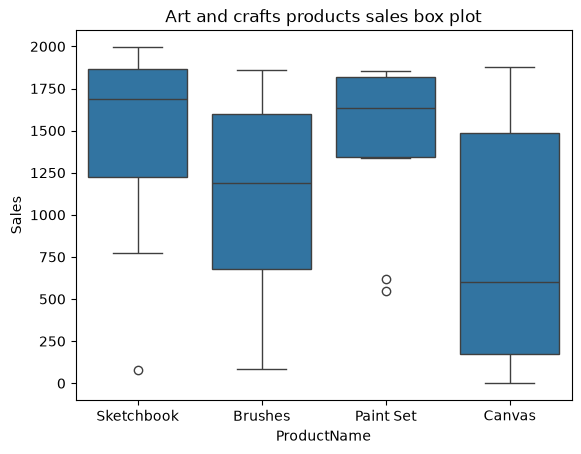

In [41]:
# Box plot of four art mats

sns.boxplot(data=acm, x='ProductName', y='Sales')

plt.title(label="Art and crafts products sales box plot")
plt.show()

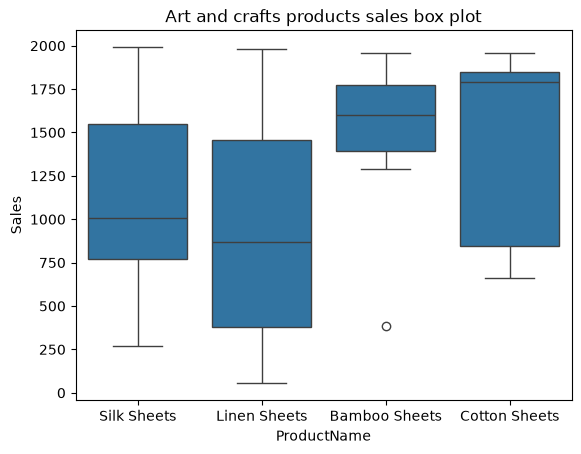

In [42]:
# KW Test on the best performing category

acm = df[df["Category"] == 'Bedsheets']

# Count of every product name

acm.groupby("ProductName")["ProductName"].count()


sns.boxplot(data=acm, x='ProductName', y='Sales')

plt.title(label="Art and crafts products sales box plot")
plt.show()